In [2]:
import IPython.display
import numpy as np
import matplotlib.pyplot as plt 
import warnings
import scipy.linalg
from utilis_ODE import *

In [ ]:
def bisezione_singola(f, a, b, toll = 1.0e-6):

    if f(a)*f(b) > 0:
        return None
    
    while (b-a)/2.0 > toll:
        c = (a+b)/2.0

        if f(a)*f(c) < 0:
            b = c
        else:
            a = c

    return (a+b)/2.0

f = lambda x:x**3 -0.5

zero_f = bisezione_singola(f,-1,1)
print(zero_f)

In [ ]:
def bisezione_multipla(f, a, b, toll = 1.0e-6, nodi = 1000):

    zeri_vect = []
    x = np.linspace(a, b, nodi)
    

    for i in range(len(x)-1):
        zero_parziale = bisezione_singola(f, x[i], x[i+1], toll)

        if zero_parziale is not None:
            if len(zeri_vect) == 0 or abs(zero_parziale - zeri_vect[-1]) > toll:
                zeri_vect.append(zero_parziale)

    if not zeri_vect:
        print("Nessuno zero troovato")

    return np.array(zeri_vect)

g = lambda x: np.exp(x)

zeri_vect = bisezione_multipla(g, -10, 10)
print(zeri_vect)

In [ ]:
def metodo_punto_fisso(phi, x0, nmax=100, toll=1.0e-6):

    xold = x0
    xvect = []
    
    for i in range(nmax):
        
        xnew = phi(xold)

        if abs(xnew - xold) < toll:
            break
        else:
            xold = xnew

    return np.array(xvect)

In [ ]:
def metodo_newton_modificato(f, df, x0, nmax = 100, toll = 1.0e-6, m = 1):

    xvect = []
    errvect = []
    xold = x0

    for i in range(nmax):
        y = f(xold)
        dy = df(xold)

        if dy == 0:
            raise RuntimeError (f"Errore: derivata nulla al passo {i+1}, punto attuale: {xold}")

        xnew = xold - m * y / dy 

        errore = abs(xnew - xold)
        xvect.append(xnew)
        errvect.append(errore)
        
        if errore <= toll:
            break

        xold = xnew
        
    else:
        warnings.warn(f"Raggiunto numero massimo di iterazioni senza convergenza. Errore residuo: {errore:.2e}")

    return np.array(xvect), np.array(errvect)

Laboratorio 1: linear system iterative methods

In [ ]:
# ESERCIZIO 1

# 1.1

n = 20
q0 = 2

# vettore b 

b = np.zeros(n)
b[0] = q0

# matrice A

A = -1*np.eye(n) + np.diag(np.ones(n-1),-1)
A[0,:] = 1

# 1.2

P, L, U = scipy.linalg.lu(A)

if (P == np.eye(n)).all():
    print("NO PIVOTING\n")
else:
    plt.spy(P)

# 1.5

y = fwsub(L, b = P.T @ b)
q = bksub(U,y)

print(q)
print("\n")

if (A @ q == b).all():
    print("Sistema risolto esattamente\n")

if np.allclose(A @ q, b):
    print("Sistema risolto correttamente a meno di una tolleranza\n")


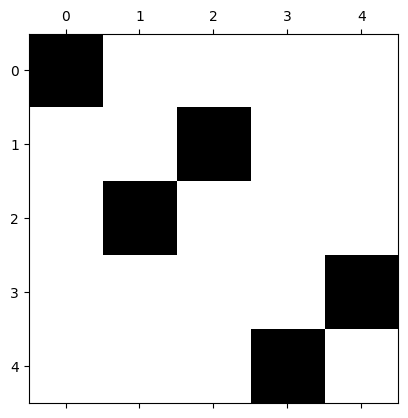

[1. 1. 1. 1. 1.]


Sistema risolto correttamente a meno di una tolleranza



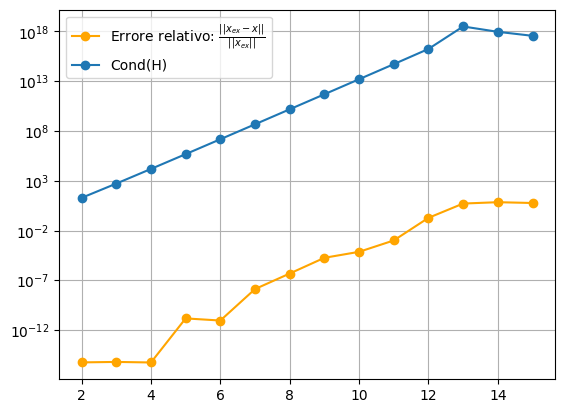

In [ ]:
# ESERCIZIO 2

# 2.1

n = 5
H = scipy.linalg.hilbert(n)

P, L, U = scipy.linalg.lu(H)

if (P == np.eye(n)).all():
    print ("NO PIVOTING\n")
else:
    plt.figure()
    plt.spy(P)
    plt.show()

# 2.2

x_ex = np.ones(n)
b = H @ x_ex

y = fwsub(L, b @ P.T)
x = bksub(U, y)

print(x)
print("\n")

if (x == x_ex).all():
    print("Sistema risolto esattamente\n")

if np.allclose(x, x_ex):
    print("Sistema risolto correttamente a meno di una tolleranza\n")

N = range(2,16)
errore_relativo = []
K = []

for n in N:
    H = scipy.linalg.hilbert(n)
    x_ex = np.ones(n)
    b = H @ x_ex

    P, L, U = scipy.linalg.lu(H)
    y = fwsub(L, P.T @ b)
    x = bksub(U, y)

    errore_relativo.append(np.linalg.norm(x - x_ex) / np.linalg.norm(x_ex))
    K.append (np.linalg.cond(H))

plt.figure()
plt.grid(True)
plt.semilogy(N,errore_relativo,'o-', color = 'orange', label = r"Errore relativo: $\frac{||x_{ex} - x||}{||x_{ex}||}$")
plt.semilogy(N,K,'o-',label = 'Cond(H)')
plt.legend()
plt.show()

# 2.3  TODO

Laboratorio 2: linear system iterative methods

In [3]:
# ESERCIZIO 1

def jacobi(A, b = None):

    n, m = A.shape

    if n != m:
        raise ValueError ("Errore: la matrice in input non è quadrata\n")
    if (np.diag(A) == 0).any():
        raise ValueError ("Errore: la matrice A è singolare\n")
    
    d = np.diag(A)

    P_inv = np.diag(1.0 / d)

    B = np.eye(n) - P_inv @ A

    if b is None:
        g = None
    else:
        g = P_inv @ b

    return B, g


def gauss_seidel(A, b = None):

    n, m = A.shape

    if n != m:
        raise ValueError ("Errore: la matrice in input non è quadrata\n")
    if (np.diag(A) == 0).any():
        raise ValueError ("Errore: la matrice in input è singolare\n")
    
    M = np.tril(A)
    N = np.triu(A, k = 1)
    B = scipy.linalg.solve_triangular(M, -N, lower = True)

    if b is None:
        g = None
    else:
        g = scipy.linalg.solve_triangular(M,b, lower = True)

    return B, g

In [4]:
# ESERCIZIO 2

def iterative_solve(A, b, x0, nmax ,rtoll, metodo_iterativo):
    """
    Metodo di risoluzione utilizzando i metodi iterativi

    Input:
    A: matrice quadrata
    b: termine noto
    x0: vettore di innesco
    B: matrice di iterazione
    g: vettore di shifting
    nmax: numero massimo di iterazioni
    rtoll: tolleranza relativa richiesta

    Output:
    xiter: lista contenente tutte le iterate

    """

    xvect = []
    xold = x0
    bnorm = np.linalg.norm(b)

    B, g = metodo_iterativo(A, b)

    for i in range(nmax):

        xnew = B @ xold + g
        xvect.append(xnew)

        if np.linalg.norm(b - A @ xnew) / bnorm < rtoll:
            break

        xold = xnew
    
    return np.array(xvect)

In [5]:
# ESERCIZIO 3

n = 100

A = -2*np.diag(np.ones(n)) + np.diag(np.ones(n-1),-1)
A[0,:] = 1

B_j, g_j = jacobi(A)
B_gs, g_gs = gauss_seidel(A)

rho_j = max(abs(scipy.linalg.eigvals(B_j)))
rho_gs = max(abs(scipy.linalg.eigvals(B_gs)))

if rho_j < 1.0:
    print(f"Raggio spettrale Jacobi: {rho_j} --> metodo convergente\n")
else:
    print(f"Raggio spettrale Jacobi: {rho_j} --> metodo non convergente\n")

if rho_gs < 1.0:
    print(f"Raggio spettrale Gauss-Seidel: {rho_gs} --> metodo convergente\n")
else:
    print(f"Raggio spettrale Gauss-Seidel: {rho_gs} --> metodo non convergente\n")

b = np.ones(n)
b[0] = 2

x0 = np.zeros(n)

x_j = iterative_solve(A, b, x0, 1000, 1.0e-6, jacobi)
print(f"Il metodo di Jacobi converge in {len(x_j)} iterazioni\n")

res_j = np.linalg.norm(b - A @ x_j[-1])
print(f"Residuo attuale metodo di Jacobi: {res_j}\n")

x_gs = iterative_solve(A, b, x0, 1000, 1.0e-6, gauss_seidel)
print(f"Il metodo di Gauss-Seidel converge in {len(x_gs)} iterazioni\n")

res_gs = np.linalg.norm(b - A @ x_gs[-1])
print(f"Residuo attuale metodo di Gauss-Seidel: {res_gs}\n")

Raggio spettrale Jacobi: 0.7071067811865485 --> metodo convergente

Raggio spettrale Gauss-Seidel: 0.9999999999999998 --> metodo convergente

Il metodo di Jacobi converge in 47 iterazioni

Residuo attuale metodo di Jacobi: 9.698604815759107e-06

Il metodo di Gauss-Seidel converge in 1000 iterazioni

Residuo attuale metodo di Gauss-Seidel: 96.00000000000001

